# Task 5 — PCA and t-SNE on MNIST (2D Visualization)

We fetch the real **MNIST** handwritten-digit dataset (60k train + 10k test,
28×28 grayscale images), take a stratified subsample for tractability, and
compare **PCA** and **t-SNE** for reducing it to 2 dimensions.

In [1]:
import io
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"

In [2]:
raw = urllib.request.urlopen(MNIST_URL, timeout=60).read()
with np.load(io.BytesIO(raw)) as npz:
    X = np.concatenate([npz["x_train"], npz["x_test"]], axis=0)
    y = np.concatenate([npz["y_train"], npz["y_test"]], axis=0)

X = X.reshape(len(X), -1).astype(np.float32) / 255.0
print(X.shape, y.shape)

(70000, 784) (70000,)


In [3]:
# stratified subsample: ~400 images per digit (4000 total) keeps PCA/t-SNE fast
N_PER_CLASS = 400
_, X_sub, _, y_sub = train_test_split(
    X, y, test_size=N_PER_CLASS * 10, random_state=42, stratify=y,
)
print(X_sub.shape, np.bincount(y_sub))

(4000, 784) [394 450 399 408 390 361 393 417 390 398]


## PCA → 2D

explained variance ratio: [0.09884495 0.07139774] sum: 0.1702427


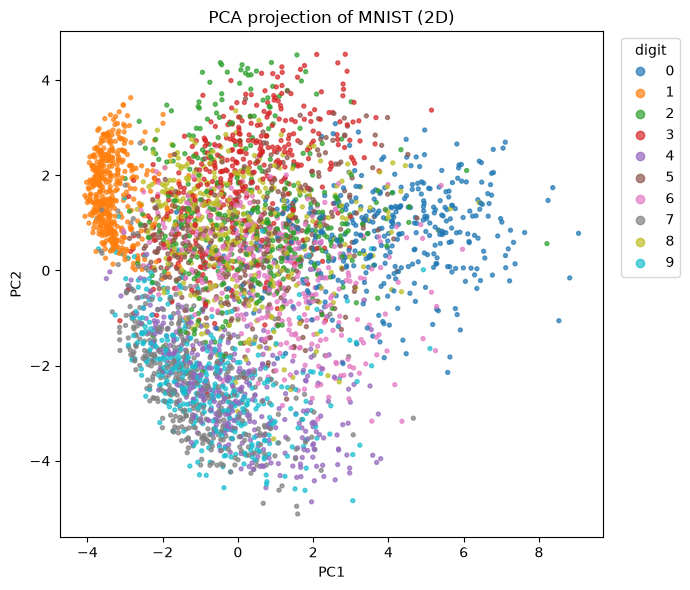

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sub)
print("explained variance ratio:", pca.explained_variance_ratio_, "sum:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sub, cmap="tab10", s=8, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("PCA projection of MNIST (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## t-SNE → 2D

t-SNE is run on a PCA-to-50D pre-reduction (standard speedup) rather than the
raw 784 pixel dimensions.

t-SNE done in 13.8s


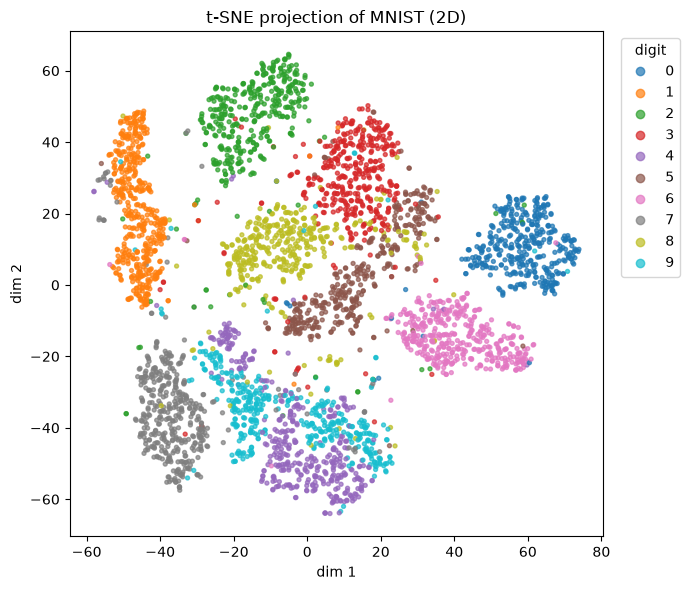

In [5]:
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_sub)

t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_pca50)
print(f"t-SNE done in {time.time() - t0:.1f}s")

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sub, cmap="tab10", s=8, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("t-SNE projection of MNIST (2D)")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.tight_layout()
plt.show()

## Conclusion

PCA's 2D projection captures only ~17% of total variance and shows heavy
overlap between digit classes, since it optimizes for global linear variance,
not class separability. t-SNE, which preserves local neighborhood structure
non-linearly, produces visibly tighter, better-separated digit clusters —
illustrating why t-SNE is generally preferred for visual cluster inspection,
while PCA remains preferable when a fast, linear, globally-variance-preserving
reduction is needed (e.g. as a preprocessing step, as done here for t-SNE itself).